# Empirical Motivation

Notebook to construct motivating facts for the capital-allocation problem using empirical data. It examines the relationship between charge-off rates, regulatory capital requirements, and the resulting allocation objective used by the empirical and simulation models.

In [80]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'empirical' / 'results').exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / 'empirical' / 'notebooks'))
from minou_colours import MINOU_COLOURS

TEXT_WIDTH = 6.22
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{charter}\usepackage[T1]{fontenc}",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "figure.titlesize": 12,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "legend.frameon": False,
    "figure.figsize": (TEXT_WIDTH, 3.0),
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

FIGURES_DIR = ROOT / 'decision_problem' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

chargeoff_path = ROOT / 'empirical' / 'data' / 'raw' / 'fred' / 'CORBLACBS.csv'
history = pd.read_csv(chargeoff_path, parse_dates=['DATE']).rename(columns={'CORBLACBS': 'charge_off_rate'}).set_index('DATE').sort_index()


In [ ]:
SIMULATION_ROOT = ROOT / 'simulation'
if str(SIMULATION_ROOT) not in sys.path:
    sys.path.insert(0, str(SIMULATION_ROOT))

# Imports decision py files from simulation setup
from common import decision as dec
from common.decision import DecisionConfig


# Defines baseline configurationß
LGD, LEVERAGE, Y_BAR, LAMBDA, PD_FLOOR = 0.45, 10.0, 0.0168, 10.0, 3e-4
M, K1, RHO_SCALE = 2.5, 1.0, 0.03
DCFG = DecisionConfig(
    LGD=LGD, K1=K1, ell=LEVERAGE, Y_BAR=Y_BAR, lambda_shortfall=LAMBDA,
    M=M, RHO_SCALE=RHO_SCALE, APPLY_PD_FLOOR=True, PD_FLOOR=PD_FLOOR,
    ALPHA_BOUNDS=(0.0, 1.0), ALPHA_OPT_XATOL=1e-10,
)

def quarterly_pd_to_annual(pd_q):
    return dec.quarterly_pd_to_annual(pd_q, DCFG)

def k_irb_from_annual_pd(pd_a):
    return dec.k_irb_from_annual_pd(pd_a, DCFG)

# Computes perfect-foresight oracle using realised charge-off rate
def oracle_from_chargeoff(c_q):
    pd_q = float(dec.clip_pd_q(c_q / LGD, DCFG))
    pd_a = float(dec.quarterly_pd_to_annual(pd_q, DCFG))
    k = float(dec.k_irb_from_annual_pd(pd_a, DCFG))
    # Uses the same continuous oracle solver as the PTO and black-box notebooks.
    return dec.optimise_alpha_oracle(c_q, k, DCFG)

history['c_q'] = history['charge_off_rate'] / 100.0 / 4.0
history = history.dropna(subset=['c_q']).copy()
history['alpha_oracle_computed'] = history['c_q'].apply(lambda c: oracle_from_chargeoff(c)[0])
df = history[['c_q', 'alpha_oracle_computed']].copy()

## Oracle behaviour over time

Plot to show how perfect-foresight oracle varies against historical charge-off rate (separate axes).

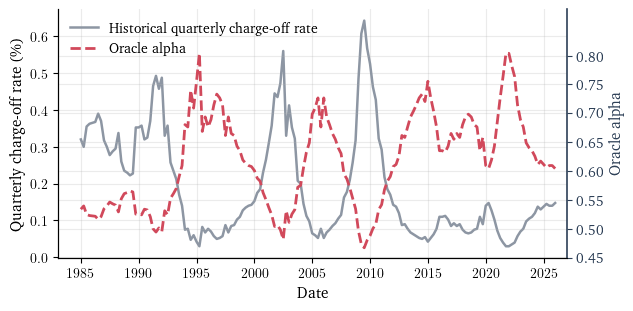

In [87]:
fig, ax = plt.subplots(constrained_layout=True)
ax2 = ax.twinx()
ax.plot(df.index, df['c_q'] * 100, color=MINOU_COLOURS['grey'], lw=1.8, label='Historical quarterly charge-off rate')
ax2.plot(df.index, df['alpha_oracle_computed'], color=MINOU_COLOURS['coral'], lw=2.0, ls='--', label='Oracle alpha')
ax.set_ylabel(r'Quarterly charge-off rate (\%)'); ax2.set_ylabel('Oracle alpha'); ax2.set_ylim(0.45, 0.88)
ax2.set_yticks(np.arange(0.45, 0.821, 0.05)); ax2.yaxis.set_major_formatter(__import__('matplotlib').ticker.FormatStrFormatter('%.2f'))
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color(MINOU_COLOURS['navy']); ax2.spines['right'].set_linewidth(1.2)
ax2.tick_params(axis='y', colors=MINOU_COLOURS['navy']); ax2.yaxis.label.set_color(MINOU_COLOURS['navy'])
ax.set_xlabel('Date'); ax.set_xlim(pd.Timestamp('1983-01-01'), pd.Timestamp('2027-01-01')); ax.xaxis.set_major_locator(mdates.YearLocator(5)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
lines = ax.get_lines() + ax2.get_lines(); ax.legend(lines, [line.get_label() for line in lines], loc='upper left')
fig.savefig(FIGURES_DIR / 'historical_oracle_against_chargeoffs.pdf', bbox_inches='tight')
plt.show()

## Basel asset correlation and IRB capital requirement

Directly pulled from Basel IRB capital requirement formulas.

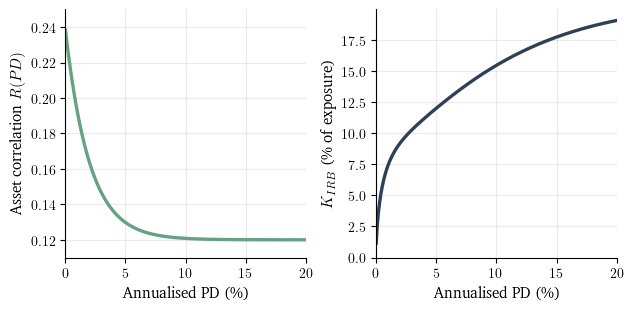

In [83]:
pd_annual_grid = np.linspace(PD_FLOOR, 0.20, 2000)
r_grid = 0.12 * (1 - np.exp(-50 * pd_annual_grid)) / (1 - np.exp(-50)) + 0.24 * (1 - (1 - np.exp(-50 * pd_annual_grid)) / (1 - np.exp(-50)))
k_grid = k_irb_from_annual_pd(pd_annual_grid)

fig, axes = plt.subplots(1, 2, constrained_layout=True)
axes[0].plot(pd_annual_grid * 100, r_grid, color=MINOU_COLOURS['sage'], lw=2.4)
axes[0].set_xlabel(r'Annualised PD (\%)'); axes[0].set_ylabel(r'Asset correlation $R(PD)$')
axes[0].set_xlim(0, 20); axes[0].set_ylim(0.11, 0.25)
axes[0].grid(True, alpha=0.25)
axes[1].plot(pd_annual_grid * 100, k_grid * 100, color=MINOU_COLOURS['navy'], lw=2.4)
axes[1].set_xlabel(r'Annualised PD (\%)'); axes[1].set_ylabel(r"$K_{IRB}$ (\% of exposure)")
axes[1].set_xlim(0, 20); axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.25)
fig.savefig(FIGURES_DIR / 'asset_correlation_and_irb_capital.pdf', bbox_inches='tight')
plt.show()

## Charge-off regimes and oracle allocation

Defines normal and stress regimes using NBER recession dates which are extended by 150% of their duration to capture lags between recessions and collapses in credit conditions. Uses regime separation to examine distributional differences and plot mean and dispersion of each. 

,Normal regime,Stress regime
Parameter,,
"μ (mean charge-off rate, %)",0.14%,0.36%
"σ (standard deviation, %)",0.10%,0.15%
Implied quarterly PD = μ / LGD (%),0.31%,0.79%
Implied annualised PD (%),1.24%,3.13%
"K_IRB (Basel capital requirement, %)",7.96%,10.40%


,Value
Parameter,
LGD,0.4500
M (maturity),2.5000
K1 (initial capital),1.0000
Leverage,10.0000
y_bar,0.0168
Lambda penalty,10.0000
PD floor,0.0003


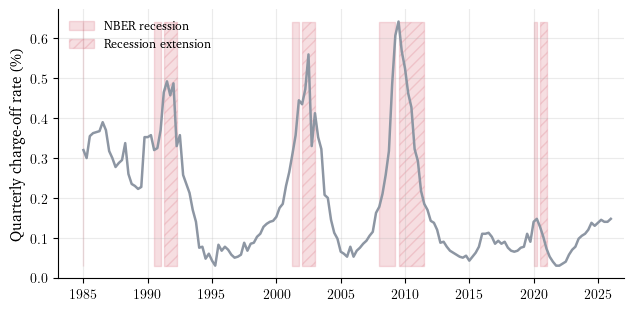

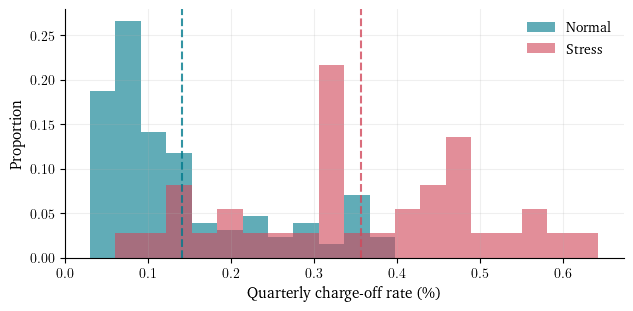

In [88]:
USREC_PATH = ROOT / 'empirical' / 'data' / 'raw' / 'fred'/ 'USREC.csv'
REGIME_EXTENSION_FRACTION = 1.50
usrec = pd.read_csv(USREC_PATH).rename(columns={'observation_date': 'DATE'})
usrec['DATE'] = pd.to_datetime(usrec['DATE'])
usrec['USREC'] = pd.to_numeric(usrec['USREC'].replace('.', np.nan), errors='coerce')
usrec = usrec.dropna(subset=['DATE', 'USREC']).set_index('DATE').sort_index()
usrec_quarterly = usrec['USREC'].astype(int).resample('QS').max().astype(bool)
recession_starts = usrec_quarterly[usrec_quarterly & ~usrec_quarterly.shift(1, fill_value=False)].index
recession_ends = usrec_quarterly[usrec_quarterly & ~usrec_quarterly.shift(-1, fill_value=False)].index
regimes = history[['c_q']].rename(columns={'c_q': 'charge_off_rate'}).copy()
regimes['nber_recession'] = usrec_quarterly.reindex(regimes.index, method='ffill').fillna(False).astype(bool)
regimes['nber_recession_extended'] = regimes['nber_recession'].copy()
for start, end in zip(recession_starts, recession_ends):
    duration_q = max(1, (end.year - start.year) * 4 + end.quarter - start.quarter + 1)
    extension_q = int(np.ceil(duration_q * REGIME_EXTENSION_FRACTION))
    extension_end = end + pd.DateOffset(months=3 * extension_q)
    extension_mask = (regimes.index > end) & (regimes.index <= extension_end)
    regimes.loc[extension_mask, 'nber_recession_extended'] = True
regimes['extension_only'] = regimes['nber_recession_extended'] & ~regimes['nber_recession']
regimes['regime'] = np.where(regimes['nber_recession_extended'], 'stress', 'normal')
regime_params = regimes.groupby('regime')['charge_off_rate'].agg(mu='mean', sigma='std').reindex(['normal', 'stress'])
regime_table = regime_params.copy()
regime_table['pd_q_mu'] = regime_table['mu'] / LGD
regime_table['pd_a_mu'] = quarterly_pd_to_annual(regime_table['pd_q_mu'].to_numpy())
regime_table['k_irb_pd_a_mu'] = k_irb_from_annual_pd(regime_table['pd_a_mu'].to_numpy())
clean_table = pd.DataFrame({
    'Parameter': ['μ (mean charge-off rate, %)', 'σ (standard deviation, %)', 'Implied quarterly PD = μ / LGD (%)', 'Implied annualised PD (%)', 'K_IRB (Basel capital requirement, %)'],
    'Normal regime': [regime_params.loc['normal', 'mu'] * 100, regime_params.loc['normal', 'sigma'] * 100, regime_table.loc['normal', 'pd_q_mu'] * 100, regime_table.loc['normal', 'pd_a_mu'] * 100, regime_table.loc['normal', 'k_irb_pd_a_mu'] * 100],
    'Stress regime': [regime_params.loc['stress', 'mu'] * 100, regime_params.loc['stress', 'sigma'] * 100, regime_table.loc['stress', 'pd_q_mu'] * 100, regime_table.loc['stress', 'pd_a_mu'] * 100, regime_table.loc['stress', 'k_irb_pd_a_mu'] * 100],
}).set_index('Parameter')
display(clean_table.style.format('{:.2f}%'))
capital_config = pd.DataFrame({
    'Parameter': ['LGD', 'M (maturity)', 'K1 (initial capital)', 'Leverage', 'y_bar', 'Lambda penalty', 'PD floor'],
    'Value': [LGD, 2.5, 1.0, LEVERAGE, Y_BAR, LAMBDA, PD_FLOOR],
}).set_index('Parameter')
display(capital_config)
chargeoff_pct = regimes['charge_off_rate'] * 100.0

COLOUR_LINE, COLOUR_NORMAL, COLOUR_STRESS = MINOU_COLOURS['grey'], MINOU_COLOURS['teal'], MINOU_COLOURS['coral']
fig, ax = plt.subplots(constrained_layout=True)
ax.plot(regimes.index, chargeoff_pct, color=COLOUR_LINE, lw=1.8)
ymin, ymax = chargeoff_pct.min(), chargeoff_pct.max()
ax.fill_between(regimes.index, ymin, ymax, where=regimes['nber_recession'].to_numpy(), color=COLOUR_STRESS, alpha=0.18, step='mid', label='NBER recession')
ax.fill_between(regimes.index, ymin, ymax, where=regimes['extension_only'].to_numpy(), color=COLOUR_STRESS, alpha=0.18, step='mid', hatch='///', label=f'Recession extension')
ax.set_ylabel(r'Quarterly charge-off rate (\%)')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.25)
ax.set_xlim(pd.Timestamp('1983-01-01'), pd.Timestamp('2027-01-01'))
ax.xaxis.set_major_locator(mdates.YearLocator(5)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.savefig(FIGURES_DIR / 'chargeoff_nber_regimes.pdf', bbox_inches='tight')

fig, ax = plt.subplots(constrained_layout=True)
normal = chargeoff_pct.loc[regimes['regime'].eq('normal')]
stress = chargeoff_pct.loc[regimes['regime'].eq('stress')]
bins = np.linspace(chargeoff_pct.min(), chargeoff_pct.max(), 21)
ax.hist(normal, bins=bins, weights=np.ones(len(normal)) / len(normal), alpha=0.62, color=COLOUR_NORMAL, label='Normal')
ax.hist(stress, bins=bins, weights=np.ones(len(stress)) / len(stress), alpha=0.62, color=COLOUR_STRESS, label='Stress')
ax.axvline(regime_params.loc['normal', 'mu'] * 100, color=COLOUR_NORMAL, ls='--', lw=1.5, alpha=0.8)
ax.axvline(regime_params.loc['stress', 'mu'] * 100, color=COLOUR_STRESS, ls='--', lw=1.5, alpha=0.8)
ax.set_xlabel(r'Quarterly charge-off rate (\%)'); ax.set_ylabel('Proportion')
ax.grid(True, alpha=0.2)
ax.legend(loc="upper right")
fig.savefig(FIGURES_DIR / 'chargeoff_regime_distribution.pdf', bbox_inches='tight')
plt.show()

## Over-versus-under-prediction cost

Regret plotted against squared errors for varying PD values to show how minimising statistical errors does not make sense when you care about downstream decision outcomes.

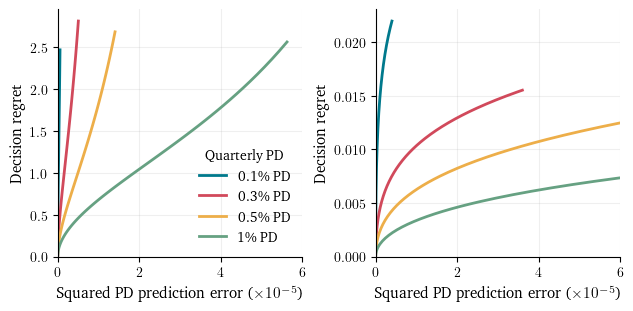

In [89]:
true_pd_levels = [0.001, 0.003, 0.005, 0.010]
forecast_multipliers = np.linspace(0.25, 3.0, 220)

def utility_at_alpha(alpha, c_q, pd_a):
    k = float(k_irb_from_annual_pd(pd_a))
    return float(dec.decision_components(float(alpha), float(c_q), k, DCFG)['utility'])

forecast_diagnostic_rows = []
for pd_true in true_pd_levels:
    c_true = LGD * pd_true
    pd_a_true = float(quarterly_pd_to_annual(pd_true))
    alpha_oracle, utility_oracle = oracle_from_chargeoff(c_true)
    for multiplier in forecast_multipliers:
        pd_forecast = float(np.clip(pd_true * multiplier, 1e-6, 0.99))
        alpha_forecast, _ = oracle_from_chargeoff(LGD * pd_forecast)
        utility_forecast = utility_at_alpha(alpha_forecast, c_true, pd_a_true)
        forecast_diagnostic_rows.append({
            'pd_true_quarterly': pd_true,
            'forecast_multiplier': multiplier,
            'forecast_error': pd_forecast - pd_true,
            'regret': max(utility_oracle - utility_forecast, 0.0),
        })

diagnostic = pd.DataFrame(forecast_diagnostic_rows)
diagnostic['squared_prediction_error_scaled'] = 1e5 * diagnostic['forecast_error'] ** 2

fig, axes = plt.subplots(1, 2, constrained_layout=True)
for panel_df, title, ax in [
    (diagnostic[diagnostic['forecast_multiplier'] < 1], '', axes[0]),
    (diagnostic[diagnostic['forecast_multiplier'] > 1], '', axes[1]),
]:
    for pd_true, colour in zip(true_pd_levels, [MINOU_COLOURS['teal'], MINOU_COLOURS['coral'], MINOU_COLOURS['gold'], MINOU_COLOURS['sage']]):
        subset = panel_df[panel_df['pd_true_quarterly'] == pd_true].sort_values('squared_prediction_error_scaled')
        ax.plot(subset['squared_prediction_error_scaled'], subset['regret'], lw=2, color=colour, label=fr'{100 * pd_true:.2g}\% PD')
    ax.set_title(title)
    ax.set_xlabel(r'Squared PD prediction error ($\times 10^{-5}$)')
    ax.set_ylabel('Decision regret')
    ax.set_xlim(0, 6)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)
axes[0].legend(title='Quarterly PD')
fig.savefig(FIGURES_DIR / 'over_under_prediction_cost.pdf', bbox_inches='tight')
plt.show()